<div class="alert alert-block alert-success">
    <b>Dynamical Systems Analysis</b>
    <p>In this notebook, we will consider a system of differential equations that represent a biological system of events. After exploring the behavior of the system over tmie, we will plot and use mathmatical anaylsis in an attempt to uncover the system at hand. </p>
    <p><b>NB:</b> consider how a mathmatical model can be used as a basis algorithm to simulate a real-world scenario of complexity. We will explore points of stability (or equilibria) in this analysis.</p>
</div>

Necessary imports

In [1]:
from random import expovariate # Generate variates from exponential distribution
import numpy as np
#import pylab as p
import matplotlib.pyplot as plt
from scipy.integrate import odeint
#from scipy.optimize import fsolve
from pylab import rcParams
import sympy as sym
from scipy import sqrt

### create plots to represent Dynamics in Time and Phase-Portrait for values of limit parameters

#### define function to handle our ODEs with various start values

In [2]:
# define system in terms of a Numpy array
#return our two ODEs
def dydt_FHN(Y, time=0): #param Y is the integrated system, param time is defined outside our function
    A=Y[0] #assign A to the first element in Y
    B=Y[1] #assign B to the second element in Y
    dydt=np.array([-beta*(B/N)*A + gamma*B, beta*(B/N)*A - gamma*B]) #make an array of the ODEs
    return dydt #return the array which will be saved in variable Y

- plot code and essential variable declarations
- show system (A and B) over time and display phase portrait

time sequence ranges from -10.0 to 10.0 with a length of 100.
We started with the initial values of:
	A=800,B=200,beta=2,gamma=1



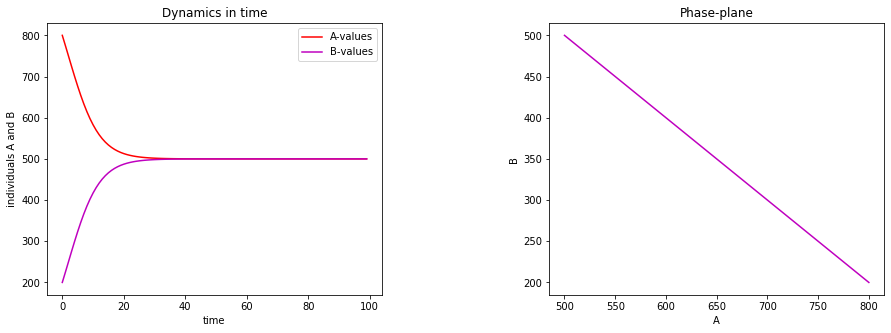

In [3]:
# generate 1000 linearly spaced numbers from 0 to 20 which will be represented in x-axis of 'dynamics in time' plot
time = np.linspace(-10, 10,  100) #use this var to pass into dydt_FHN function
#inital values
N=1000 #number of individuals (population)
B0=200 #remember that A + B = N (so, B must be the difference of N and A)
A0=N-B0 #remember that A + B = N (so, A must be the difference of N and B)
beta=2 #beta rate
gamma=1 #gamma rate
Y0 = np.array([A0, B0]) #we start with an inital position containing intial values of A and B
Y = odeint(dydt_FHN, Y0, time) #get integrated ODE using python odeint function
A,B = Y.T #prints the first two tuples, which are the integration for A0 and B0 respectively
equilibria=[[N,0],[(N*gamma)/beta,(N*(beta-gamma))/beta],[0,0]] #we calculated this analytically


'''plot'''
#customise some of the plot
fig = plt.figure(figsize=(15,5))
fig.subplots_adjust(wspace = 0.5, hspace = 0.3)
axdt1 = fig.add_subplot(1,2,1)
axpp1 = fig.add_subplot(1,2,2)

#plot dynamics in time i.e., plotting time against 
axdt1.plot(A, 'r-', label='A-values')
axdt1.plot(B, 'm-', label='B-values')
axdt1.set_xlabel("time")
axdt1.set_ylabel("individuals A and B")
axdt1.set_title("Dynamics in time")
axdt1.legend(loc='best')

#plot phase portrait i.e., plotting A against B
axpp1.plot(A, B, 'm')
axpp1.set_xlabel("A")
axpp1.set_ylabel("B")  
axpp1.set_title("Phase-plane")

#print some details about the plots for ease
print("time sequence ranges from {} to {} with a length of {}.\n"
        "We started with the initial values of:\n\tA={},B={},beta={},gamma={}\n"
        "".format(time[0],time[len(time)-1],len(time),A0,B0,beta,gamma))

### user input for values of limit parameters
Below you can ask the machine to prompt you to enter values of key parameters N, B0, beta, and gamma. R0 and A0 are calculated for you. Use this functionality to verify plots in simulation part are displaying properly. Plots in simulation part, after various scenario and realisation manipulations, should behave simular to the single lines of A and B plotted in the **Dynamics in Time** plot below.

Enter value for N: 100
Enter value for B0: 80
Enter value for beta: 2
Enter value for gamma: 1

your initial values are:
N=100, A0 (N-B0)=20, B0=80, beta=2, gamma=1, R0 (beta/gamma)=2.0

time sequence ranges from -10.0 to 10.0 with a length of 100.
We started with the initial values of:
	A=20,B=80,beta=2,gamma=1



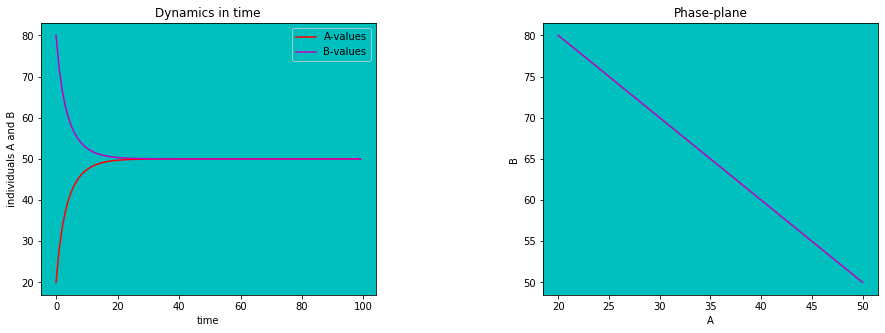

In [8]:
N=input("Enter value for N: ")
N=int(N)
B0=input("Enter value for B0: ")
B0=int(B0)
beta=input("Enter value for beta: ")
beta=int(beta)
gamma=input("Enter value for gamma: ")
gamma=int(gamma)
A0=N-B0
R0=beta/gamma
print("\nyour initial values are:\nN={}, A0 (N-B0)={}, B0={}, beta={}, gamma={}, R0 (beta/gamma)={}".format(
        N,A0,B0,beta,gamma,R0))

'''get ODE values'''
Y0 = np.array([A0, B0]) #we start with an inital position containing intial values of A and B
Y = odeint(dydt_FHN, Y0, time) #get integrated ODE using python odeint function
A,B = Y.T #prints the first two tuples, which are the integration for A0 and B0 respectively
equilibria=[[N,0],[(N*gamma)/beta,(N*(beta-gamma))/beta],[0,0]] #we calculated this analytically

'''plot'''
#customise some of the plot
fig2 = plt.figure(figsize=(15,5))
fig2.subplots_adjust(wspace = 0.5, hspace = 0.3)
axdt2 = fig2.add_subplot(1,2,1)
axpp2 = fig2.add_subplot(1,2,2)

#plot dynamics in time i.e., plotting time against 
axdt2.plot(A, 'r-', label='A-values')
axdt2.plot(B, 'm-', label='B-values')
axdt2.set_xlabel("time")
axdt2.set_ylabel("individuals A and B")
axdt2.set_title("Dynamics in time")
axdt2.legend(loc='best')

#plot phase portrait i.e., plotting A against B
axpp2.plot(A, B, 'm')
axpp2.set_xlabel("A")
axpp2.set_ylabel("B")  
axpp2.set_title("Phase-plane")

#print some details about the plots for ease
print("\ntime sequence ranges from {} to {} with a length of {}.\n"
        "We started with the initial values of:\n\tA={},B={},beta={},gamma={}\n"
        "".format(time[0],time[len(time)-1],len(time),A0,B0,beta,gamma))

Demonstrate stability using nulllclines (or isoclines) and quiver analysis

equilibria are [[100, 0], [50.0, 50.0], [0, 0]] when beta=2,gamma=1
ynullpts=[[50.0, 50.0], [0, 100]], xnullpts=[[100, 0], [0, 100]]


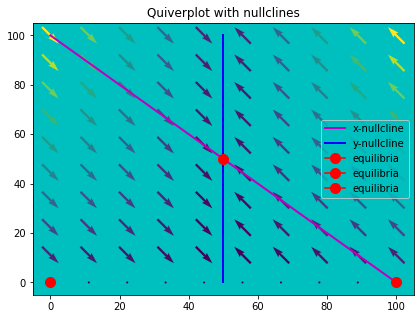

In [9]:
#plot
fig = plt.figure(figsize=(15,5))
ax_fxdpt1 = fig.add_subplot(1,2,1)

# declare and plot nullclines
xnullpts=[[N,0],
          [0,N]]
ynullpts=[[(N*gamma)/beta,(N*gamma)/beta],
          [0,N]]
ax_fxdpt1.plot(xnullpts[0],xnullpts[1],'m', lw=2, label='x-nullcline')
ax_fxdpt1.plot(ynullpts[0],ynullpts[1],'b', lw=2, label='y-nullcline')

# plot fixed points
for point in equilibria:
    ax_fxdpt1.plot(point[0],point[1],"r", marker = "o", markersize = 10.0, label='equilibria')
ax_fxdpt1.set_title("Quiverplot with nullclines")
ax_fxdpt1.legend(loc='best')

# quiverplot
# define a grid and compute direction at each point
x = np.linspace(N, 0, 10)
y = np.linspace(N, 0, 10)

X1, Y1  = np.meshgrid(x, y)# create a grid

DX1, DY1 = dydt_FHN([X1, Y1])# compute growth rate on the grid
M = (np.hypot(DX1, DY1))# norm growth rate 
M[ M == 0] = 1.# avoid zero division errors 
DX1 /= M # normalize each arrows
DY1 /= M

ax_fxdpt1.quiver(X1, Y1, DX1, DY1, M, pivot='mid')
print("equilibria are {} when beta={},gamma={}\nynullpts={}, xnullpts={}".format(
    equilibria,beta,gamma,ynullpts,xnullpts))

#### Bifurcation Plot

need to incorporate euler's method

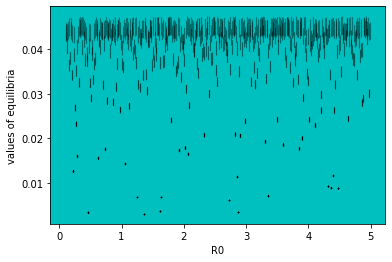

In [10]:
#euler's method: 𝑥 𝑡 + ℎ = 𝑥 𝑡 + ℎ A 𝐹(𝑥 𝑡 , 𝑡)

'''mean-field function'''
def f(x,R0):
    B=x
    #we will use [B]dot as mean-field equation
    bdot = (beta*B)-((beta*B**2)/N)-(gamma*B)

    return bdot # logistic map with parameter r >= 1

def bifurcation(R0, iter):
    
    # One initial condition for each value of r
    #we take an nd-array of random float64s with length taken from R0 ndarray; store them inside variable x
    x = np.random.rand(len(R0))
    
    # We are first going to get rid of the transients
    for i in range(1000):
        x = f(x,R0)

    # Assuming we are now on the limit cycle, we plot value of iter outputs
    for i in range(iter): 
        x = f(x,R0)
        plt.plot(R0,x,'.', color = 'k', markersize = 0.05)
        
'''plot bifurcation'''
plt.figure()
plt.rcParams['axes.facecolor'] = 'c'
plt.xlabel('R0')
plt.ylabel('values of equilibria')

'''for plotting bifurcation'''
R0 = np.arange(0.1, 5.0, 0.01) #type: nd-array #taking values from 0.1 to 5.0, with increments of 0.01 as required
iter = 100
bifurcation(R0, iter)
plt.show()